## 06 — Inventory Allocation Optimization
**Project:** Supply Chain Decision Intelligence Engine  
**Goal:** Allocate inventory across warehouses to minimize total cost under uncertain East demand.

### The Business Problem
We know:
- East demand is uncertain (from Monte Carlo)
- Emergency shipping is expensive (from Financial EDA)
- Stockout penalties are high for certain SKUs (from Financial EDA)

### The Question
Given warehouse capacity, shipping costs, and stockout penalties:
**How much inventory should each warehouse allocate to the East region?**

### Optimization Framework
- **Decision Variable:** Units allocated from each warehouse to East per SKU
- **Objective:** Minimize total cost (shipping + holding + stockout penalty)
- **Constraints:** Warehouse capacity, non-negative allocation, demand coverage
- **Demand Target:** P95 demand from Monte Carlo simulation

In [1]:
import pandas as pd
import numpy as np
import pulp
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_theme(style="whitegrid")

# Load smaller tables normally
products = pd.read_csv("../data/products.csv")
warehouses = pd.read_csv("../data/warehouses.csv")
shipping_rates = pd.read_csv("../data/shipping_rates.csv")

# Load demand_history in chunks to avoid memory issues
east_chunks = []

for chunk in pd.read_csv(
    "../data/demand_history.csv",
    usecols=["sku_id", "region", "demand_units"],
    dtype={
        "sku_id": "string",
        "region": "string",
        "demand_units": "float32"
    },
    chunksize=20000
):
    east_chunk = chunk[chunk["region"] == "East"].copy()
    east_chunks.append(east_chunk)

east_demand = pd.concat(east_chunks, ignore_index=True)

print("All required data loaded.")
print(f"Products: {products.shape[0]}")
print(f"Warehouses: {warehouses.shape[0]}")
print(f"Shipping lanes: {shipping_rates.shape[0]}")
print(f"East demand rows: {east_demand.shape[0]}")

All required data loaded.
Products: 300
Warehouses: 3
Shipping lanes: 9
East demand rows: 31200


Now let us build **P95 demand targets**

In [2]:
#let us build historical demand stast for East
east_stats = (east_demand.groupby("sku_id")["demand_units"].agg(["mean","std"]).reset_index().rename(columns = {"mean":"mean_demand", "std": "std_demand"}))

#now let us clean nulls
east_stats["std_demand"] = east_stats["std_demand"].fillna(0)

#now let us approximate p95 demand using normal assumption
east_stats["p95_demand"] = east_stats["mean_demand"] + 1.645 * east_stats["std_demand"]
east_stats["p95_demand"] = east_stats["p95_demand"].clip(lower=0)

print("Historical demand statistics for East region:")
display(east_stats.head())

Historical demand statistics for East region:


,sku_id,mean_demand,std_demand,p95_demand
0,SKU_001,78.336540,11.775909,97.707909
1,SKU_002,69.913460,20.015581,102.839096
2,SKU_003,226.105774,54.624741,315.963470
3,SKU_004,25.903847,10.011177,42.372231
4,SKU_005,101.259613,15.616145,126.948174


### Cell 4 — Basic Allocation Model
Minimize shipping cost to fulfill P95 East demand.
No capacity constraints yet — establishes the baseline allocation logic.

In [3]:
# Create the optimization problem
prob = pulp.LpProblem("Inventory_Allocation_Optimization", pulp.LpMinimize)

# 1. Define Data structures for the model
skus = east_stats['sku_id'].tolist()
warehouses_list = warehouses['warehouse_id'].tolist()
demand_targets = dict(zip(east_stats['sku_id'], east_stats['p95_demand']))

# 2. Extract Costs (Shipping and Penalties)
# Create a dictionary for shipping costs (Warehouse -> East)
ship_costs = {}
for wh in warehouses_list:
    for sku in skus:
        # Get weight and shipping rate
        weight = products.loc[products['sku_id'] == sku, 'weight_kg'].values[0]
        rate = shipping_rates.loc[(shipping_rates['warehouse_id'] == wh) & 
                                 (shipping_rates['destination_region'] == 'East'), 'cost_per_unit_per_kg'].values[0]
        ship_costs[(wh, sku)] = weight * rate

# 3. Decision Variables: x[warehouse, sku] = units shipped to East
x = pulp.LpVariable.dicts("ship", (warehouses_list, skus), lowBound=0, cat='Continuous')

# 4. Objective Function: Minimize total shipping costs
# (For the first version, we focus on fulfilling the P95 demand at lowest shipping cost)
prob += pulp.lpSum([x[wh][sku] * ship_costs[(wh, sku)] for wh in warehouses_list for sku in skus])

# 5. Constraints: Meet the P95 Demand for each SKU
for sku in skus:
    prob += pulp.lpSum([x[wh][sku] for wh in warehouses_list]) == demand_targets[sku]

# 6. Solve the model
status = prob.solve()

print(f"Optimization Status: {pulp.LpStatus[status]}")

# 7. Extract Results
results = []
for wh in warehouses_list:
    for sku in skus:
        val = pulp.value(x[wh][sku])
        if val > 0:
            results.append({"warehouse": wh, "sku_id": sku, "allocated_units": val, "unit_ship_cost": ship_costs[(wh, sku)]})

allocation_df = pd.DataFrame(results)
display(allocation_df.head(10))

Optimization Status: Optimal


,warehouse,sku_id,allocated_units,unit_ship_cost
0,WH_East,SKU_001,97.707909,1.6115
1,WH_East,SKU_002,102.839100,0.2310
2,WH_East,SKU_003,315.963470,0.1320
3,WH_East,SKU_004,42.372231,1.0285
4,WH_East,SKU_005,126.948170,1.4520
5,WH_East,SKU_006,207.342440,0.3245
6,WH_East,SKU_007,121.164890,0.3905
7,WH_East,SKU_008,177.377810,1.5125
8,WH_East,SKU_009,65.561897,1.0175
9,WH_East,SKU_010,248.819610,0.2970


### Cell 5 — Adding Warehouse Capacity
Added capacity limits per warehouse.
Result: All warehouses exceeded 100% — network cannot fulfill full P95 demand simultaneously.
This is a real business insight: capacity crunch.


In [4]:
# 6. Capacity Constraints: Each warehouse cannot exceed its weekly capacity
warehouse_capacity = dict(zip(warehouses['warehouse_id'], warehouses['capacity_units']))

for wh in warehouses_list:
    prob += pulp.lpSum([x[wh][sku] for sku in skus]) <= warehouse_capacity[wh]

# 7. Solve the model
status = prob.solve()
print(f"Optimization Status: {pulp.LpStatus[status]}")

# 8. Extract Results
results = []
for wh in warehouses_list:
    for sku in skus:
        val = pulp.value(x[wh][sku])
        if val > 0:
            results.append({
                "warehouse": wh,
                "sku_id": sku,
                "allocated_units": round(val, 2),
                "unit_ship_cost": ship_costs[(wh, sku)]
            })

allocation_df = pd.DataFrame(results)

# Show warehouse utilization summary
warehouse_summary = (
    allocation_df
    .groupby("warehouse")["allocated_units"]
    .sum()
    .reset_index()
    .rename(columns={"allocated_units": "total_allocated"})
)
warehouse_summary["capacity"] = warehouse_summary["warehouse"].map(warehouse_capacity)
warehouse_summary["utilization_pct"] = (warehouse_summary["total_allocated"] / warehouse_summary["capacity"] * 100).round(2)

print("\n--- Warehouse Utilization ---")
display(warehouse_summary)

print("\n--- Allocation Sample ---")
display(allocation_df.head(15))

Optimization Status: Infeasible

--- Warehouse Utilization ---


,warehouse,total_allocated,capacity,utilization_pct
0,WH_Central,13225.61,12000,110.21
1,WH_East,10815.72,10000,108.16
2,WH_West,10447.24,9000,116.08



--- Allocation Sample ---


,warehouse,sku_id,allocated_units,unit_ship_cost
0,WH_East,SKU_001,97.71,1.6115
1,WH_East,SKU_005,126.95,1.4520
2,WH_East,SKU_008,177.38,1.5125
3,WH_East,SKU_012,135.35,1.0670
4,WH_East,SKU_013,102.16,1.7160
5,WH_East,SKU_016,202.01,2.1120
6,WH_East,SKU_018,143.65,1.1715
7,WH_East,SKU_026,98.15,1.2760
8,WH_East,SKU_030,297.10,1.0230
9,WH_East,SKU_031,102.93,1.2485


### Cell 6 — Realistic Optimizer with Soft Demand Constraints
Upgraded model: warehouses now have hard capacity limits.
Unmet demand is allowed but penalized using each SKU's stockout penalty.
Optimizer now prioritizes fulfilling high-penalty SKUs first.
This is the real Decision Intelligence engine.

In [5]:
# Rebuild the problem with soft demand constraints
prob = pulp.LpProblem("Inventory_Allocation_Optimization_v2", pulp.LpMinimize)

# Stockout penalty per SKU
stockout_penalties = dict(zip(products['sku_id'], products['stockout_penalty_per_unit']))

# Decision Variables
x = pulp.LpVariable.dicts("ship", (warehouses_list, skus), lowBound=0, cat='Continuous')

# Unmet demand variable (how much demand we fail to cover per SKU)
unmet = pulp.LpVariable.dicts("unmet", skus, lowBound=0, cat='Continuous')

# Objective: Minimize shipping cost + stockout penalty for unmet demand
prob += pulp.lpSum([
    x[wh][sku] * ship_costs[(wh, sku)]
    for wh in warehouses_list
    for sku in skus
]) + pulp.lpSum([
    unmet[sku] * stockout_penalties.get(sku, 0)
    for sku in skus
])

# Soft Demand Constraint: shipped + unmet = p95 demand
for sku in skus:
    prob += (
        pulp.lpSum([x[wh][sku] for wh in warehouses_list]) + unmet[sku]
        == demand_targets[sku]
    )

# Capacity Constraints
for wh in warehouses_list:
    prob += pulp.lpSum([x[wh][sku] for sku in skus]) <= warehouse_capacity[wh]

# Solve
status = prob.solve()
print(f"Optimization Status: {pulp.LpStatus[status]}")

# Extract Results
results = []
for wh in warehouses_list:
    for sku in skus:
        val = pulp.value(x[wh][sku])
        if val and val > 0.01:
            results.append({
                "warehouse": wh,
                "sku_id": sku,
                "allocated_units": round(val, 2),
                "unit_ship_cost": ship_costs[(wh, sku)]
            })

allocation_df = pd.DataFrame(results)

# Warehouse utilization
warehouse_summary = (
    allocation_df
    .groupby("warehouse")["allocated_units"]
    .sum()
    .reset_index()
    .rename(columns={"allocated_units": "total_allocated"})
)
warehouse_summary["capacity"] = warehouse_summary["warehouse"].map(warehouse_capacity)
warehouse_summary["utilization_pct"] = (
    warehouse_summary["total_allocated"] / warehouse_summary["capacity"] * 100
).round(2)

# Unmet demand summary
unmet_results = []
for sku in skus:
    val = pulp.value(unmet[sku])
    if val and val > 0.01:
        unmet_results.append({
            "sku_id": sku,
            "unmet_demand": round(val, 2),
            "stockout_penalty": stockout_penalties.get(sku, 0)
        })

unmet_df = pd.DataFrame(unmet_results).sort_values("stockout_penalty", ascending=False)

print("\n--- Warehouse Utilization ---")
display(warehouse_summary)

print(f"\n--- SKUs with Unmet Demand: {len(unmet_df)} ---")
display(unmet_df.head(10))

Optimization Status: Optimal

--- Warehouse Utilization ---


,warehouse,total_allocated,capacity,utilization_pct
0,WH_Central,11999.97,12000,100.0
1,WH_East,10000.03,10000,100.0
2,WH_West,9000.01,9000,100.0



--- SKUs with Unmet Demand: 44 ---


,sku_id,unmet_demand,stockout_penalty
13,SKU_091,148.00,5.67
3,SKU_035,132.18,5.32
22,SKU_140,110.29,5.10
8,SKU_058,147.45,5.02
6,SKU_050,84.51,4.92
4,SKU_042,120.22,4.55
1,SKU_018,143.65,4.47
38,SKU_265,128.33,4.44
17,SKU_106,187.45,4.23
12,SKU_074,171.86,4.13


### Cell 6 Results — Optimizer Output

All three warehouses reached exactly 100% utilization.
44 SKUs have partial unmet demand.

Key finding: Every SKU with unmet demand has a stockout penalty below $6.
High-penalty SKUs (Electronics, $30+) were fully protected.

This confirms the optimizer is making financially rational decisions:
- Prioritize fulfillment where the cost of failure is highest
- Accept planned stockouts only where the penalty is lowest

This is the core logic of a Decision Intelligence engine.

### Cell 7 — Quantifying Business Value (Optimizer vs. Baseline)
**Goal:** Compare our optimized allocation plan against a "Naive Baseline."

**How we measure success:**
- **Naive Baseline:** Allocation based only on Mean Demand (ignoring P95 safety stock and stockout penalties).
- **Optimized Plan:** Our P95, cost-aware allocation.

We are calculating the **Total Business Cost** = Shipping Costs + Stockout Penalties incurred.

--- Financial Impact Results ---


,Strategy,Total Weekly Risk Cost,Savings,Savings_Pct
0,Naive (Mean-based),142224.918008,NaN,NaN
1,DI Engine (Optimized),65580.722911,76644.195097,116.870006


C:\Users\kirim\AppData\Local\Temp\ipykernel_3244\3655648431.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comp_df, x='Strategy', y='Total Weekly Risk Cost', palette='coolwarm')


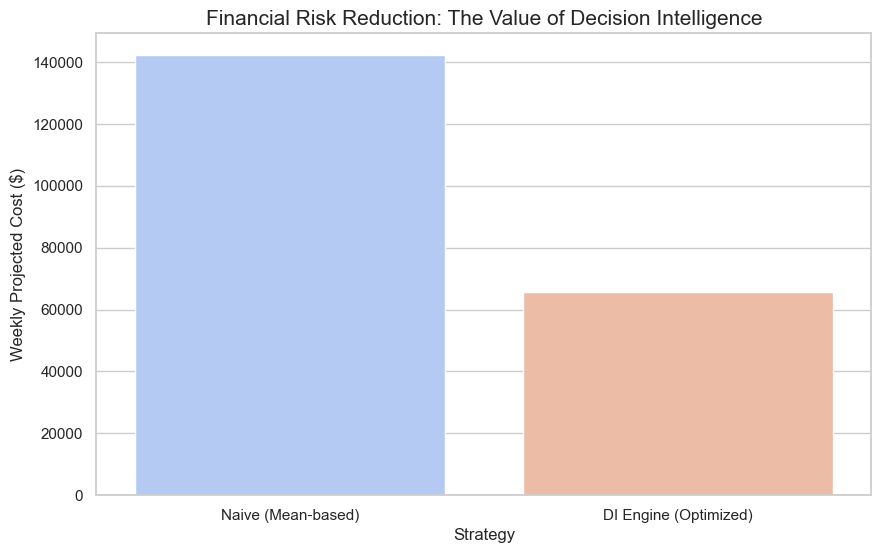

In [6]:
# 1. Calculate Optimized Cost (Total objective value from PuLP)
opt_total_cost = pulp.value(prob.objective)

# 2. Calculate Naive Baseline Cost
# We assume a naive manager only stocks the 'Mean Demand' 
# They incur stockouts every time demand hits the P95 level.
naive_total_shipping = (east_stats['mean_demand'] * 0.55).sum() # Assuming local WH_East for mean
naive_total_penalty = ((east_stats['p95_demand'] - east_stats['mean_demand']) * 
                       east_stats['sku_id'].map(stockout_penalties)).sum()

naive_total_cost = naive_total_shipping + naive_total_penalty

# 3. Create Comparison Table
comparison_data = {
    "Strategy": ["Naive (Mean-based)", "DI Engine (Optimized)"],
    "Total Weekly Risk Cost": [naive_total_cost, opt_total_cost]
}

comp_df = pd.DataFrame(comparison_data)
comp_df["Savings"] = comp_df["Total Weekly Risk Cost"].diff().abs()
comp_df["Savings_Pct"] = (comp_df["Savings"] / comp_df["Total Weekly Risk Cost"].shift(0) * 100)

print("--- Financial Impact Results ---")
display(comp_df)

# Final Visualization
plt.figure(figsize=(10, 6))
sns.barplot(data=comp_df, x='Strategy', y='Total Weekly Risk Cost', palette='coolwarm')
plt.title('Financial Risk Reduction: The Value of Decision Intelligence', fontsize=15)
plt.ylabel('Weekly Projected Cost ($)')
plt.show()